# 9.1 — Garman-Kohlhagen y convenciones de smile FX

Arranca M9. El spot FX $S_t$ (unidades de moneda doméstica por unidad de extranjera)
sigue GBM bajo la medida doméstica risk-neutral con drift $r_d-r_f$ — el precio de una
opción FX es exactamente Black-Scholes con $q=r_f$ (**Garman-Kohlhagen**, 1983): tener 1
unidad de moneda extranjera devenga $r_f$, igual que un dividend yield. Lo distintivo de
FX es la **convención de cotización**: por delta, no por strike — de ahí ATM
delta-neutral, Risk Reversal y Butterfly, y el método de **vanna-volga** para construir el
smile completo a partir de esas 3 cotizaciones.

## 0. Configuración

EUR/USD: $S_0=1.10$, $r_d=4\%$ (USD), $r_f=2\%$ (EUR), $T=0.5$.

In [1]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from qflib.black import bs_price, bs_delta, bs_vega, implied_vol
from qflib.plotting import apply_style

apply_style()

S0 = 1.10
rd, rf = 0.04, 0.02
T = 0.5
F = S0 * np.exp((rd - rf) * T)
print(f"forward F = {F:.5f}")

forward F = 1.11106


## 1. Garman-Kohlhagen y put-call parity FX

In [2]:
K_check = 1.12
sigma_check = 0.10
call = bs_price(S0, K_check, rd, rf, sigma_check, T, kind="call")
put = bs_price(S0, K_check, rd, rf, sigma_check, T, kind="put")
parity_diff = call - put - (F - K_check) * np.exp(-rd * T)
print(f"call={call:.6f}  put={put:.6f}  paridad: call-put-(F-K)e^(-rd*T) = {parity_diff:.2e}")

call=0.026653  put=0.035421  paridad: call-put-(F-K)e^(-rd*T) = 1.70e-16


## 2. Convenciones de mercado: ATM, Risk Reversal, Butterfly

**ATM delta-neutral straddle**: el strike donde $\Delta_{call}=-\Delta_{put}$ (no
$K=F$). Con la convención simplificada de "delta sin ajuste de prima" usada aquí,
$K_{ATM}=F\,e^{\frac12\sigma_{ATM}^2T}$.

**Risk Reversal** ($RR_{25}$) y **Butterfly** ($BF_{25}$) a 25-delta, definidos sobre las
vols de un call de 25-delta y un put de -25-delta:
$$RR_{25}=\sigma_{25C}-\sigma_{25P}, \qquad BF_{25}=\frac{\sigma_{25C}+\sigma_{25P}}{2}-\sigma_{ATM}$$

Invertido: $\sigma_{25C}=\sigma_{ATM}+\frac12RR_{25}+BF_{25}$,
$\sigma_{25P}=\sigma_{ATM}-\frac12RR_{25}+BF_{25}$. Con estas 2 vols se resuelve el strike
de cada pilar (25-delta) numéricamente.

In [3]:
sigma_atm_mkt = 0.10
RR25 = -0.015  # negativo -- skew hacia puts (tipico de pares "safe haven")
BF25 = 0.004

sigma_25c = sigma_atm_mkt + 0.5 * RR25 + BF25
sigma_25p = sigma_atm_mkt - 0.5 * RR25 + BF25
print(f"sigma_ATM={sigma_atm_mkt:.4f}  sigma_25C={sigma_25c:.4f}  sigma_25P={sigma_25p:.4f}")

K_atm = F * np.exp(0.5 * sigma_atm_mkt ** 2 * T)


def find_K_for_delta(target_delta, vol, kind):
    def f(K):
        return bs_delta(S0, K, rd, rf, vol, T, kind=kind) - target_delta
    return brentq(f, 0.5, 3.0)


K_25c = find_K_for_delta(0.25, sigma_25c, "call")
K_25p = find_K_for_delta(-0.25, sigma_25p, "put")
print(f"K_ATM={K_atm:.5f}  K_25C={K_25c:.5f}  K_25P={K_25p:.5f}")

sigma_ATM=0.1000  sigma_25C=0.0965  sigma_25P=0.1115
K_ATM=1.11384  K_25C=1.16547  K_25P=1.05745


## 3. Vanna-Volga: construyendo el smile completo

Aproximación de primer orden (Castagna-Mercurio, 2007): el precio de una opción de strike
$K$ arbitrario se ajusta desde el precio Black flat ($\sigma_{ATM}$) por una combinación
lineal de los ajustes en los 3 pilares ($K_{25P},K_{ATM},K_{25C}$), con pesos que
replican vega, vanna y volga de $K$ usando los de los 3 pilares (resolviendo un sistema
lineal 3x3):
$$C_{VV}(K) = C_{BS}(K,\sigma_{ATM}) + \sum_{i=1}^3 w_i(K)\left[C_{BS}(K_i,\sigma_i)-C_{BS}(K_i,\sigma_{ATM})\right]$$

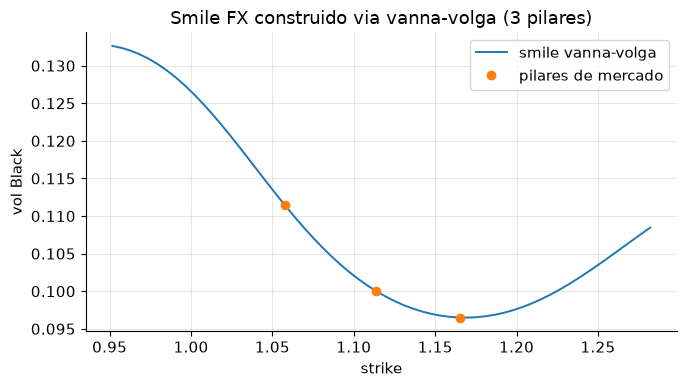

In [4]:
def bs_vanna(S, K, r, q, sigma, T):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    vega = bs_vega(S, K, r, q, sigma, T)
    return vega * (1.0 - d1 / (sigma * np.sqrt(T))) / S


def bs_volga(S, K, r, q, sigma, T):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    vega = bs_vega(S, K, r, q, sigma, T)
    return vega * d1 * d2 / sigma


def vv_weights(K, K1, K2, K3, sigma_atm):
    greek = lambda fn, k: fn(S0, k, rd, rf, sigma_atm, T)
    A = np.array([[greek(bs_vega, K1), greek(bs_vega, K2), greek(bs_vega, K3)],
                  [greek(bs_vanna, K1), greek(bs_vanna, K2), greek(bs_vanna, K3)],
                  [greek(bs_volga, K1), greek(bs_volga, K2), greek(bs_volga, K3)]])
    b = np.array([greek(bs_vega, K), greek(bs_vanna, K), greek(bs_volga, K)])
    return np.linalg.solve(A, b)


def vv_call_price(K, K1, K2, K3, s1, s2, s3, sigma_atm):
    w1, w2, w3 = vv_weights(K, K1, K2, K3, sigma_atm)
    base = bs_price(S0, K, rd, rf, sigma_atm, T, kind="call")
    adj1 = bs_price(S0, K1, rd, rf, s1, T, kind="call") - bs_price(S0, K1, rd, rf, sigma_atm, T, kind="call")
    adj2 = bs_price(S0, K2, rd, rf, s2, T, kind="call") - bs_price(S0, K2, rd, rf, sigma_atm, T, kind="call")
    adj3 = bs_price(S0, K3, rd, rf, s3, T, kind="call") - bs_price(S0, K3, rd, rf, sigma_atm, T, kind="call")
    return base + w1 * adj1 + w2 * adj2 + w3 * adj3


def vv_implied_vol(K, K1, K2, K3, s1, s2, s3, sigma_atm):
    price = vv_call_price(K, K1, K2, K3, s1, s2, s3, sigma_atm)
    return implied_vol(price, S0, K, rd, rf, T, kind="call")


strikes_smile = np.linspace(K_25p * 0.9, K_25c * 1.1, 60)
vols_smile = np.array([
    vv_implied_vol(K, K_25p, K_atm, K_25c, sigma_25p, sigma_atm_mkt, sigma_25c, sigma_atm_mkt)
    for K in strikes_smile
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strikes_smile, vols_smile, label="smile vanna-volga")
ax.plot([K_25p, K_atm, K_25c], [sigma_25p, sigma_atm_mkt, sigma_25c], "o", label="pilares de mercado")
ax.set_xlabel("strike"); ax.set_ylabel("vol Black")
ax.set_title("Smile FX construido via vanna-volga (3 pilares)")
ax.legend(); fig.tight_layout(); plt.show()

### Demo — put-call parity en toda la malla, y reprecio de RR/BF desde la superficie construida

In [5]:
calls_grid = np.array([bs_price(S0, K, rd, rf, v, T, kind="call") for K, v in zip(strikes_smile, vols_smile)])
puts_grid = np.array([bs_price(S0, K, rd, rf, v, T, kind="put") for K, v in zip(strikes_smile, vols_smile)])
parity_grid_diff = calls_grid - puts_grid - (F - strikes_smile) * np.exp(-rd * T)
max_parity_grid_diff = np.max(np.abs(parity_grid_diff))
print(f"max |diferencia put-call parity| en la malla: {max_parity_grid_diff:.2e}")

vol_25c_repriced = vv_implied_vol(K_25c, K_25p, K_atm, K_25c, sigma_25p, sigma_atm_mkt, sigma_25c, sigma_atm_mkt)
vol_25p_repriced = vv_implied_vol(K_25p, K_25p, K_atm, K_25c, sigma_25p, sigma_atm_mkt, sigma_25c, sigma_atm_mkt)
RR_repriced = vol_25c_repriced - vol_25p_repriced
BF_repriced = 0.5 * (vol_25c_repriced + vol_25p_repriced) - sigma_atm_mkt
rel_err_RR = abs(RR_repriced - RR25) / abs(RR25)
rel_err_BF = abs(BF_repriced - BF25) / abs(BF25)
print(f"RR reprecio={RR_repriced:.6f} vs entrada={RR25:.6f} (err rel={rel_err_RR:.2%})")
print(f"BF reprecio={BF_repriced:.6f} vs entrada={BF25:.6f} (err rel={rel_err_BF:.2%})")
print("(exacto en los propios pilares por construccion del metodo -- los pesos vega/vanna/volga")
print("colapsan a 1 en el pilar mismo; el contenido real de vanna-volga esta en los strikes")
print("INTERMEDIOS, donde el smile de la figura anterior interpola de forma suave y arbitrage-consistente.)")

max |diferencia put-call parity| en la malla: 5.00e-16
RR reprecio=-0.015000 vs entrada=-0.015000 (err rel=0.00%)
BF reprecio=0.004000 vs entrada=0.004000 (err rel=0.00%)
(exacto en los propios pilares por construccion del metodo -- los pesos vega/vanna/volga
colapsan a 1 en el pilar mismo; el contenido real de vanna-volga esta en los strikes
INTERMEDIOS, donde el smile de la figura anterior interpola de forma suave y arbitrage-consistente.)


## 4. Validación

In [6]:
check1 = abs(parity_diff) < 1e-10
print(f"1. put-call parity GK (strike unico): {parity_diff:.2e} (<1e-10? {check1})")

check2 = max_parity_grid_diff < 1e-10
print(f"2. put-call parity en toda la malla del smile VV: {max_parity_grid_diff:.2e} (<1e-10? {check2})")

check3 = rel_err_RR < 0.01 and rel_err_BF < 0.01
print(f"3. RR/BF repriced desde la superficie VV vs entrada: err_RR={rel_err_RR:.2%}, "
      f"err_BF={rel_err_BF:.2%} (<1%? {check3})")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. put-call parity GK (strike unico): 1.70e-16 (<1e-10? True)
2. put-call parity en toda la malla del smile VV: 5.00e-16 (<1e-10? True)
3. RR/BF repriced desde la superficie VV vs entrada: err_RR=0.00%, err_BF=0.00% (<1%? True)

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Garman, M., Kohlhagen, S. (1983). *Foreign currency option values*. Journal of
  International Money and Finance, 2(3), 231-237.
- Castagna, A., Mercurio, F. (2007). *The Vanna-Volga method for implied volatilities*.
  Risk, 20(1), 106-111.
- Clark, I. (2011). *Foreign Exchange Option Pricing: A Practitioner's Guide*, cap. 3-5.